# MALL CUSTOMER SEGMENTATION DATA ANALYSIS


C:\Users\kralj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


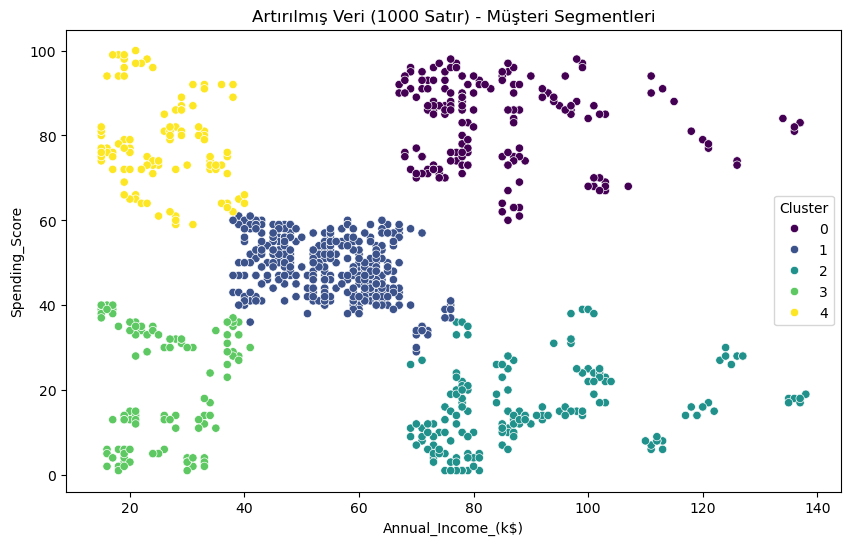

İşlem Başarılı! Yeni Veri Seti Boyutu: (1000, 11)


In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# DOSYA KONTROLÜ VE YÜKLEME
file_name = 'Mall_Customers.xls'

if not os.path.exists(file_name):
    print(f"HATA: '{file_name}' dosyası bulunamadı!")
    print("Lütfen CSV dosyasının notebook ile aynı klasörde olduğundan veya yüklendiğinden emin olun.")
else:
    # 1. Orijinal Veriyi Yükle
    df_orig = pd.read_csv(file_name)

    # 2. Veri Artırımı (200 -> 1000 Veri)
    def augment_data(df, target_rows=1000):
        current_rows = len(df)
        needed_rows = target_rows - current_rows
        
        # Mevcut veriden rastgele seçim yap (Resampling)
        indices = np.random.choice(df.index, size=needed_rows)
        df_synthetic = df.iloc[indices].copy()
        
        # Sayısal sütunlara küçük gürültüler ekle (Std'nin %5'i kadar)
        for col in ['Age', 'Annual_Income_(k$)', 'Spending_Score']:
            std = df[col].std()
            noise = np.random.normal(0, std * 0.05, size=needed_rows)
            df_synthetic[col] = df_synthetic[col] + noise
            
            # Değerlerin mantıklı sınırlar içinde kalmasını sağla (clip)
            if col == 'Age':
                df_synthetic[col] = df_synthetic[col].clip(18, 70)
            elif col == 'Spending_Score':
                df_synthetic[col] = df_synthetic[col].clip(1, 100)
            elif col == 'Annual_Income_(k$)':
                df_synthetic[col] = df_synthetic[col].clip(15, 140)
                
        # CustomerID'yi yeniden düzenle (Çakışmaları önlemek için)
        df_synthetic['CustomerID'] = range(current_rows + 1, target_rows + 1)
        
        # Tam sayı olması gereken sütunları düzelt
        df_synthetic[['Age', 'Annual_Income_(k$)', 'Spending_Score']] = df_synthetic[['Age', 'Annual_Income_(k$)', 'Spending_Score']].astype(int)
        
        return pd.concat([df, df_synthetic], ignore_index=True)

    # Veriyi 1000'e çıkaralım
    df = augment_data(df_orig, 1000)

    # 3. Normalizasyon
    scaler = MinMaxScaler()
    df[['Age_norm', 'Income_norm', 'Spending_norm']] = scaler.fit_transform(
        df[['Age', 'Annual_Income_(k$)', 'Spending_Score']]
    )

    # 4. Özellik Mühendisliği: Card_Credit_Score
    df["Card_Credit_Score"] = (
        0.5 * df["Income_norm"] + 
        0.3 * df["Spending_norm"] + 
        0.2 * df["Age_norm"]
    ) * 100

    # 5. Risk Segmentasyonu
    df["Risk_Segment"] = pd.qcut(
        df["Card_Credit_Score"], 
        q=3, 
        labels=["High Risk", "Medium Risk", "Low Risk"]
    )

    # 6. K-Means Kümeleme
    X_clustering = df[["Annual_Income_(k$)", "Spending_Score"]]
    kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
    df["Cluster"] = kmeans.fit_predict(X_clustering)

    # Sonuçları Görselleştirme
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="Annual_Income_(k$)", y="Spending_Score", hue="Cluster", data=df, palette="viridis")
    plt.title("Artırılmış Veri (1000 Satır) - Müşteri Segmentleri")
    plt.show()

    print(f"İşlem Başarılı! Yeni Veri Seti Boyutu: {df.shape}")

In [6]:
df.head(1000)

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score,Age_norm,Income_norm,Spending_norm,Card_Credit_Score,Risk_Segment,Cluster
0,1,Male,19,15,39,0.019231,0.000000,0.383838,11.899767,High Risk,3
1,2,Male,21,15,81,0.057692,0.000000,0.808081,25.396270,High Risk,4
2,3,Female,20,16,6,0.038462,0.008130,0.050505,2.690886,High Risk,3
3,4,Female,23,16,77,0.096154,0.008130,0.767677,25.359884,High Risk,4
4,5,Female,31,17,40,0.250000,0.016260,0.393939,17.631190,High Risk,3
...,...,...,...,...,...,...,...,...,...,...,...
995,996,Male,59,52,46,0.788462,0.300813,0.454545,44.446245,Medium Risk,1
996,997,Male,65,63,45,0.903846,0.390244,0.444444,50.922452,Low Risk,1
997,998,Male,30,137,18,0.230769,0.991870,0.171717,59.360396,Low Risk,2
998,999,Male,18,31,92,0.000000,0.130081,0.919192,34.079823,High Risk,4


In [7]:
df[["Annual_Income_(k$)", "Spending_Score", "Age", "Card_Credit_Score"]].head(250)

,Annual_Income_(k$),Spending_Score,Age,Card_Credit_Score
0,15,39,19,11.899767
1,15,81,21,25.396270
2,16,6,20,2.690886
3,16,77,23,25.359884
4,17,40,31,17.631190
...,...,...,...,...
245,21,36,34,19.198931
246,29,86,22,32.987094
247,80,90,34,59.546307
248,39,33,65,37.529990


In [8]:
df.shape
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   CustomerID          1000 non-null   int64   
 1   Genre               1000 non-null   object  
 2   Age                 1000 non-null   int64   
 3   Annual_Income_(k$)  1000 non-null   int64   
 4   Spending_Score      1000 non-null   int64   
 5   Age_norm            1000 non-null   float64 
 6   Income_norm         1000 non-null   float64 
 7   Spending_norm       1000 non-null   float64 
 8   Card_Credit_Score   1000 non-null   float64 
 9   Risk_Segment        1000 non-null   category
 10  Cluster             1000 non-null   int32   
dtypes: category(1), float64(4), int32(1), int64(4), object(1)
memory usage: 75.5+ KB


,CustomerID,Age,Annual_Income_(k$),Spending_Score,Age_norm,Income_norm,Spending_norm,Card_Credit_Score,Cluster
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,38.768000,60.916000,48.850000,0.399385,0.373301,0.483333,41.152733,1.581000
std,288.819436,14.060436,27.169747,26.379184,0.270393,0.220892,0.266456,13.241935,1.242974
min,1.000000,18.000000,15.000000,1.000000,0.000000,0.000000,0.000000,2.003241,0.000000
25%,250.750000,28.000000,40.000000,30.000000,0.192308,0.203252,0.292929,32.030815,1.000000
50%,500.500000,35.000000,61.000000,48.000000,0.326923,0.373984,0.474747,40.227415,1.000000
75%,750.250000,49.000000,78.000000,72.000000,0.596154,0.512195,0.717172,50.895162,2.000000
max,1000.000000,70.000000,138.000000,100.000000,1.000000,1.000000,1.000000,79.057365,4.000000


In [11]:
print(df.shape)
print(df.columns)
df.head(350)

(1000, 11)
Index(['CustomerID', 'Genre', 'Age', 'Annual_Income_(k$)', 'Spending_Score',
       'Age_norm', 'Income_norm', 'Spending_norm', 'Card_Credit_Score',
       'Risk_Segment', 'Cluster'],
      dtype='object')


,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score,Age_norm,Income_norm,Spending_norm,Card_Credit_Score,Risk_Segment,Cluster
0,1,Male,19,15,39,0.019231,0.000000,0.383838,11.899767,High Risk,3
1,2,Male,21,15,81,0.057692,0.000000,0.808081,25.396270,High Risk,4
2,3,Female,20,16,6,0.038462,0.008130,0.050505,2.690886,High Risk,3
3,4,Female,23,16,77,0.096154,0.008130,0.767677,25.359884,High Risk,4
4,5,Female,31,17,40,0.250000,0.016260,0.393939,17.631190,High Risk,3
...,...,...,...,...,...,...,...,...,...,...,...
345,346,Female,32,15,40,0.269231,0.000000,0.393939,17.202797,High Risk,3
346,347,Female,28,73,88,0.192308,0.471545,0.878788,53.787026,Low Risk,0
347,348,Female,64,39,33,0.884615,0.195122,0.323232,37.145375,Medium Risk,3
348,349,Female,56,77,4,0.730769,0.504065,0.030303,40.727728,Medium Risk,2


In [12]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   CustomerID          1000 non-null   int64   
 1   Genre               1000 non-null   object  
 2   Age                 1000 non-null   int64   
 3   Annual_Income_(k$)  1000 non-null   int64   
 4   Spending_Score      1000 non-null   int64   
 5   Age_norm            1000 non-null   float64 
 6   Income_norm         1000 non-null   float64 
 7   Spending_norm       1000 non-null   float64 
 8   Card_Credit_Score   1000 non-null   float64 
 9   Risk_Segment        1000 non-null   category
 10  Cluster             1000 non-null   int32   
dtypes: category(1), float64(4), int32(1), int64(4), object(1)
memory usage: 75.5+ KB


CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
Age_norm              0
Income_norm           0
Spending_norm         0
Card_Credit_Score     0
Risk_Segment          0
Cluster               0
dtype: int64

In [13]:
df["Genre"].value_counts()
df["Genre"].value_counts(normalize=True)

Genre
Female    0.55
Male      0.45
Name: proportion, dtype: float64

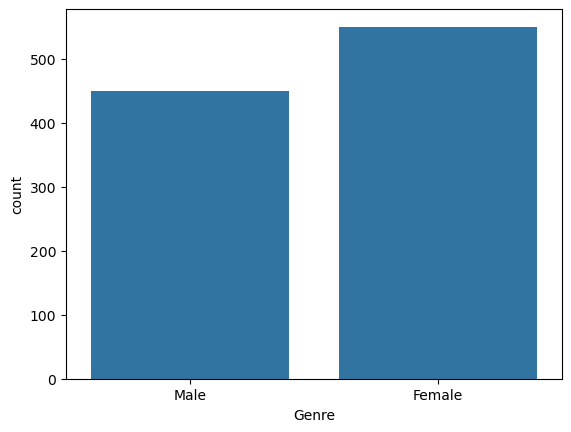

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Genre", data=df)
plt.show()

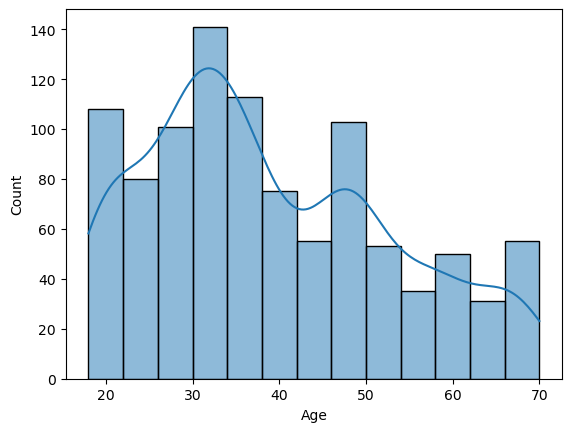

In [15]:
sns.histplot(df["Age"], kde=True)
plt.show()

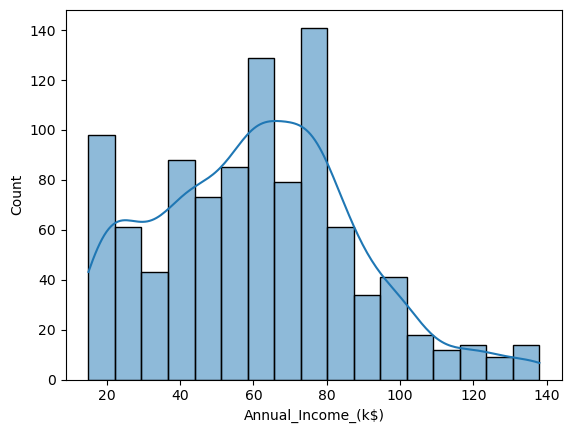

In [16]:
sns.histplot(df["Annual_Income_(k$)"], kde=True)
plt.show()

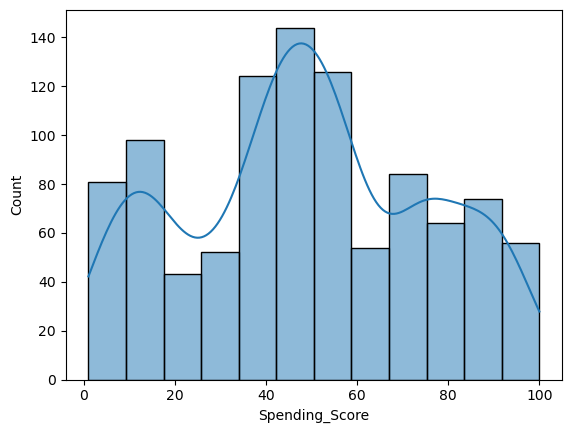

In [17]:
sns.histplot(df["Spending_Score"], kde=True)
plt.show()

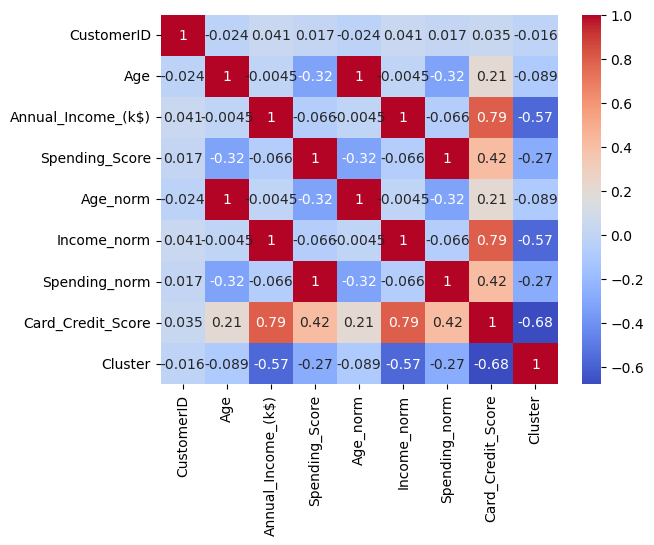

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

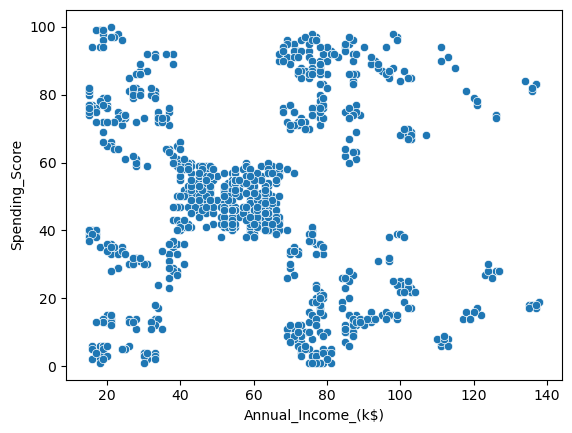

In [19]:
sns.scatterplot(
    x="Annual_Income_(k$)",
    y="Spending_Score",
    data=df
)
plt.show()

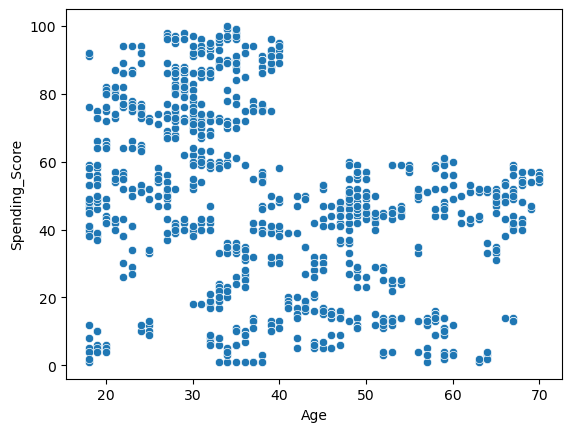

In [20]:
sns.scatterplot(
    x="Age",
    y="Spending_Score",
    data=df
)
plt.show()

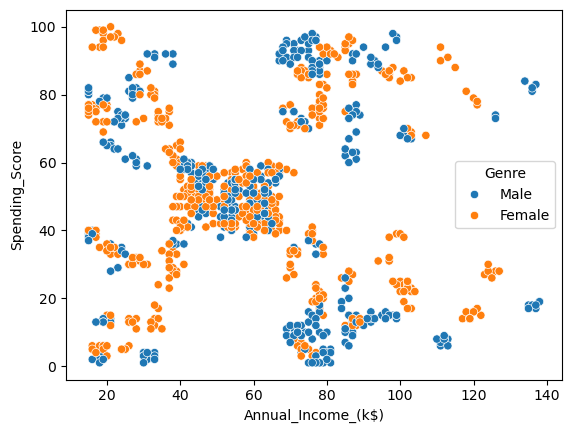

In [21]:
sns.scatterplot(
    x="Annual_Income_(k$)",
    y="Spending_Score",
    hue="Genre",
    data=df
)
plt.show()

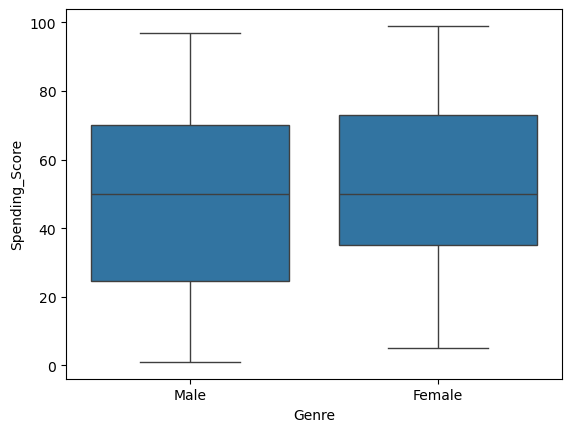

In [26]:
sns.boxplot(x="Genre", y="Spending_Score", data=df)
plt.show()

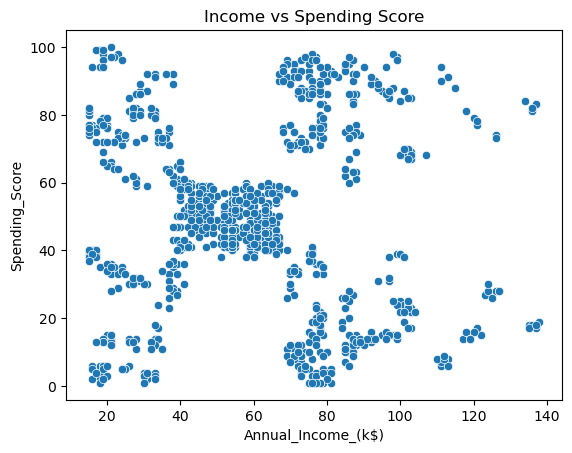

In [22]:
sns.scatterplot(
    x="Annual_Income_(k$)",
    y="Spending_Score",
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

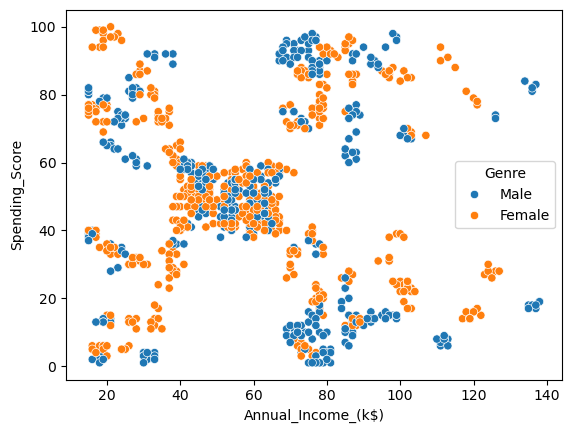

In [23]:
sns.scatterplot(
    x="Annual_Income_(k$)",
    y="Spending_Score",
    hue="Genre",
    data=df
)
plt.show()

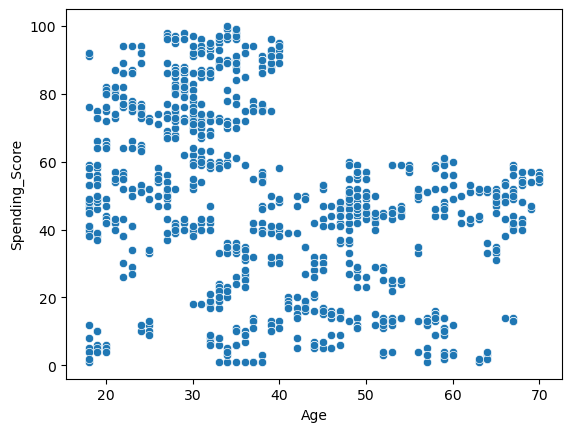

In [24]:
sns.scatterplot(
    x="Age",
    y="Spending_Score",
    data=df
)
plt.show()

In [25]:
X = df[["Annual_Income_(k$)", "Spending_Score"]]

In [26]:
X

,Annual_Income_(k$),Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
995,52,46
996,63,45
997,137,18
998,31,92


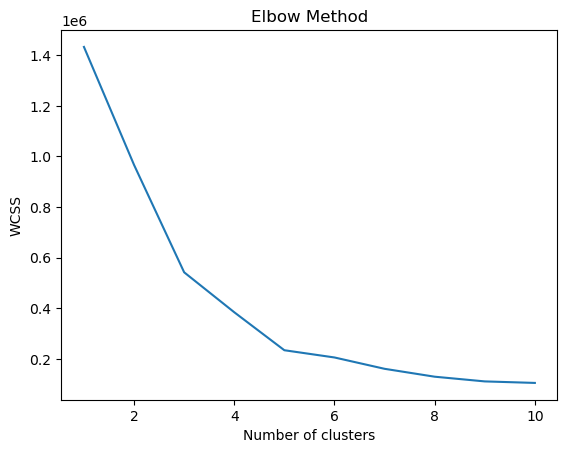

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [29]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual_Income_(k$),Spending_Score,Age_norm,Income_norm,Spending_norm,Card_Credit_Score
Cluster,,,,,,,,
0,516.788360,32.322751,85.269841,82.296296,0.275438,0.571300,0.821175,58.708968
1,491.178295,42.943152,55.180879,48.589147,0.479676,0.326674,0.480698,40.348164
2,524.487047,41.020725,90.854922,15.704663,0.442706,0.616707,0.148532,44.145418
3,456.336207,44.956897,25.818966,21.215517,0.518402,0.087959,0.204197,20.891905
4,509.391304,25.286957,25.347826,78.260870,0.140134,0.084129,0.780413,30.421494


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age_norm', 'Income_norm', 'Spending_norm']] = scaler.fit_transform(
    df[['Age', 'Annual_Income_(k$)', 'Spending_Score']]
)

In [31]:
df["Card_Credit_Score"] = (
    0.5 * df["Income_norm"] +
    0.3 * df["Spending_norm"] +
    0.2 * df["Age_norm"]
) * 100 

In [32]:
df[["Annual_Income_(k$)", "Spending_Score", "Age", "Card_Credit_Score"]].head(50)

,Annual_Income_(k$),Spending_Score,Age,Card_Credit_Score
0,15,39,19,11.899767
1,15,81,21,25.396270
2,16,6,20,2.690886
3,16,77,23,25.359884
4,17,40,31,17.631190
5,17,76,22,25.078742
6,18,6,35,9.273125
7,18,94,23,31.324407
8,19,3,64,19.924385
9,19,72,30,27.756552


In [33]:
df["Card_Credit_Score"] = (
    0.6 * (
        (df["Annual_Income_(k$)"] - df["Annual_Income_(k$)"].min()) /
        (df["Annual_Income_(k$)"].max() - df["Annual_Income_(k$)"].min())
    )
    +
    0.2 * (
        1 - (
            (df["Spending_Score"] - df["Spending_Score"].min()) /
            (df["Spending_Score"].max() - df["Spending_Score"].min())
        )
    )
    +
    0.2 * (
        (df["Age"] - df["Age"].min()) /
        (df["Age"].max() - df["Age"].min())
    )
) * 100

In [34]:
df["Risk_Segment"] = pd.qcut(
    df["Card_Credit_Score"],
    q=3,
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

In [35]:
top10 = df.sort_values(by="Card_Credit_Score", ascending=False).head(10)

top10[["CustomerID",
       "Annual_Income_(k$)",
       "Spending_Score",
       "Age",
       "Card_Credit_Score"]]

,CustomerID,Annual_Income_(k$),Spending_Score,Age,Card_Credit_Score
833,834,138,19,33,82.132867
633,634,138,19,32,81.748252
385,386,137,17,32,81.664487
198,199,137,18,32,81.462467
219,220,137,18,32,81.462467
537,538,135,17,33,81.073493
349,350,136,18,32,80.974662
997,998,137,18,30,80.693236
262,263,122,15,47,80.520685
286,287,135,18,31,80.102242


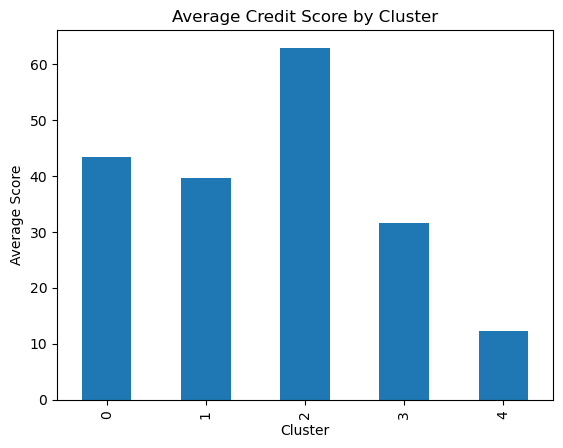

In [36]:
import matplotlib.pyplot as plt

df.groupby("Cluster")["Card_Credit_Score"].mean().plot(kind="bar")

plt.title("Average Credit Score by Cluster")
plt.ylabel("Average Score")
plt.show()

In [37]:
df.groupby("Cluster")["Card_Credit_Score"].mean()

Cluster
0    43.363228
1    39.579980
2    62.885887
3    31.561638
4    12.242139
Name: Card_Credit_Score, dtype: float64

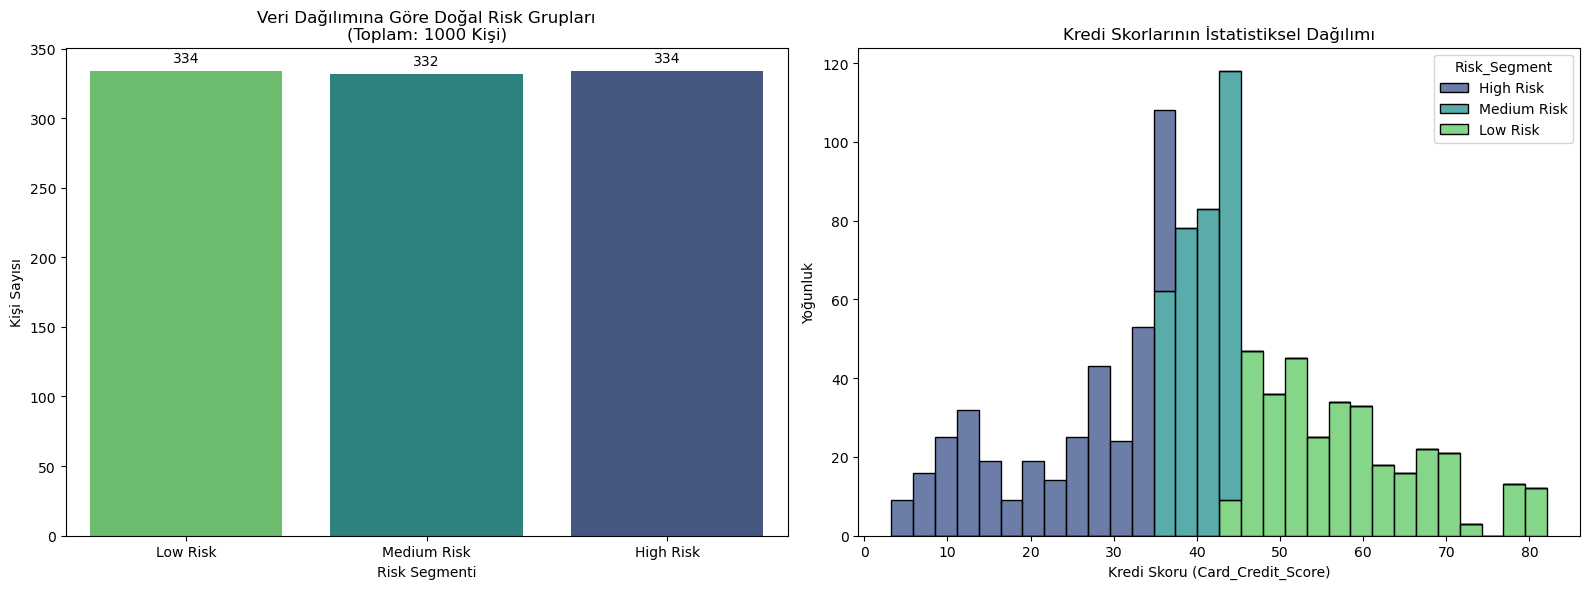

Kodlamaya Göre Otomatik Belirlenen Oranlar:
Risk_Segment
High Risk      33.4
Low Risk       33.4
Medium Risk    33.2
Name: proportion, dtype: float64


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kodlamadaki Asıl Mantığa Dönüş (Eşit Frekanslı Bölüm - q=3)
df["Risk_Segment"] = pd.qcut(
    df["Card_Credit_Score"], 
    q=3, 
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

# 2. Görselleştirme
plt.figure(figsize=(16, 6))

# Sol Grafik: Doğal Risk Dağılımı (Sütun Grafiği)
# UYARIYI GİDEREN GÜNCELLEME: x değişkenini hue'ya atayıp legend=False yapıyoruz.
plt.subplot(1, 2, 1)
ax = sns.countplot(
    x="Risk_Segment", 
    data=df, 
    hue="Risk_Segment", 
    palette="viridis", 
    legend=False,
    order=["Low Risk", "Medium Risk", "High Risk"]
)
plt.title(f"Veri Dağılımına Göre Doğal Risk Grupları\n(Toplam: {len(df)} Kişi)")
plt.xlabel("Risk Segmenti")
plt.ylabel("Kişi Sayısı")

# Sütunların üzerine gerçek sayıları yazdıralım
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Sadece değeri olan sütunlara yazdır
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

# Sağ Grafik: Kredi Skoru Histogramı
plt.subplot(1, 2, 2)
sns.histplot(
    data=df, 
    x="Card_Credit_Score", 
    hue="Risk_Segment", 
    element="bars", 
    palette="viridis", 
    multiple="stack", 
    bins=30
)
plt.title("Kredi Skorlarının İstatistiksel Dağılımı")
plt.xlabel("Kredi Skoru (Card_Credit_Score)")
plt.ylabel("Yoğunluk")

plt.tight_layout()
plt.show()

# Gerçekleşen oranları yazdıralım
print("Kodlamaya Göre Otomatik Belirlenen Oranlar:")
print(df["Risk_Segment"].value_counts(normalize=True) * 100)